In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("/kaggle/input/datasets/jp797498e/twitter-entity-sentiment-analysis/twitter_training.csv",
                   header=None)


data.columns = ['id', 'entity', 'sentiment', 'Review']

print("Shape:", data.shape)
data.head()

Shape: (74682, 4)


,id,entity,sentiment,Review
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [3]:
print(data['sentiment'].value_counts())
print()
print(data.info())
print()
print(data.describe())

sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         74682 non-null  int64 
 1   entity     74682 non-null  object
 2   sentiment  74682 non-null  object
 3   Review     73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB
None

                 id
count  74682.000000
mean    6432.586165
std     3740.427870
min        1.000000
25%     3195.000000
50%     6422.000000
75%     9601.000000
max    13200.000000


In [4]:
# Drop rows with missing Review text
data = data.dropna(subset=['Review'])

# Encode sentiment labels
le = LabelEncoder()
data['sentiment_enc'] = le.fit_transform(data['sentiment'])
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Label mapping: {'Irrelevant': np.int64(0), 'Negative': np.int64(1), 'Neutral': np.int64(2), 'Positive': np.int64(3)}


In [5]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)

STOPWORDS = set(stopwords.words('english'))

def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", "", text)      # remove URLs
    text = re.sub(r"@\w+|#\w+", "", text)           # remove mentions / hashtags
    text = re.sub(r"<.*?>", "", text)                  # remove HTML tags
    text = re.sub(r"[^a-zA-Z]", " ", text)            # keep only letters
    text = text.lower()
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    return " ".join(tokens)


data['clean_text'] = data['Review'].apply(clean_text)
data[['Review', 'clean_text', 'sentiment']].head()

,Review,clean_text,sentiment
0,im getting on borderlands and i will murder yo...,getting borderlands murder,Positive
1,I am coming to the borders and I will kill you...,coming borders kill,Positive
2,im getting on borderlands and i will kill you ...,getting borderlands kill,Positive
3,im coming on borderlands and i will murder you...,coming borderlands murder,Positive
4,im getting on borderlands 2 and i will murder ...,getting borderlands murder,Positive


In [6]:
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),   # unigrams + bigrams
    min_df=2,
    max_df=0.85,
    sublinear_tf=True     # apply log normalization – helps SVM
)

X = vectorizer.fit_transform(data['clean_text'])
Y = data['sentiment_enc']
print("Feature matrix shape:", X.shape)

Feature matrix shape: (73996, 20000)


In [7]:
#split BEFORE fitting the model (was after in original)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

Train: 59196 samples | Test: 14800 samples


In [8]:
# added max_iter to avoid convergence warning
model = LinearSVC(C=1.0, max_iter=2000)
model.fit(X_train, Y_train)
print("Model trained successfully.")

Model trained successfully.


In [9]:
Y_pred = model.predict(X_test)

acc = accuracy_score(Y_test, Y_pred)
print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print()
print("Classification Report:")
print(classification_report(Y_test, Y_pred, target_names=le.classes_))

Accuracy: 0.8539 (85.39%)

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.87      0.79      0.83      2575
    Negative       0.82      0.91      0.86      4472
     Neutral       0.88      0.82      0.85      3622
    Positive       0.86      0.86      0.86      4131

    accuracy                           0.85     14800
   macro avg       0.86      0.85      0.85     14800
weighted avg       0.86      0.85      0.85     14800



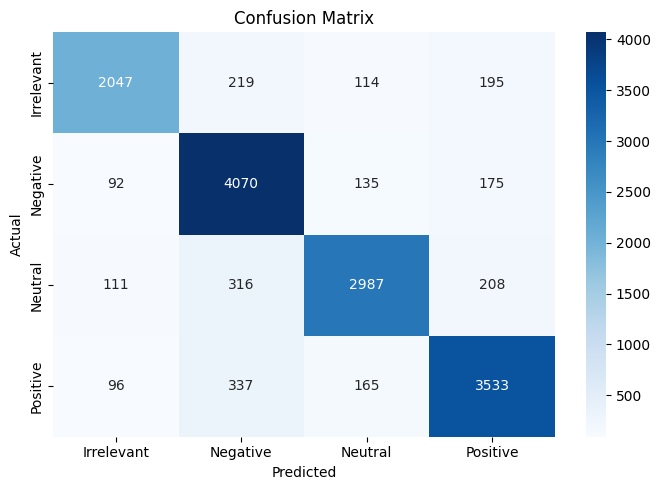

In [10]:
cm = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [11]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    return le.inverse_transform([pred])[0]

samples = [
    "I absolutely love this game, it's amazing!",
    "This product is terrible and broken.",
    "It's okay, nothing special.",
    "Borderlands is the best game ever!"
]

for s in samples:
    print(f"Text: {s!r}  →  Sentiment: {predict_sentiment(s)}")

Text: "I absolutely love this game, it's amazing!"  →  Sentiment: Positive
Text: 'This product is terrible and broken.'  →  Sentiment: Negative
Text: "It's okay, nothing special."  →  Sentiment: Irrelevant
Text: 'Borderlands is the best game ever!'  →  Sentiment: Positive
